In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from Tiler import Tiler
from Tokenizer import Tokenizer

In [3]:
import os
from utils import load_all_images

# Store original directory
original_dir = os.getcwd()

# Change to LlamaGen directory
TOKENIZER_PATH = '/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/LlamaGen'
os.chdir(TOKENIZER_PATH)

In [4]:
import torch
import torch.nn.functional as F
import numpy as np
from PIL import Image
from omegaconf import OmegaConf
from tokenizer.vqgan.model import VQModel
from tokenizer.vqgan.model import VQGAN_FROM_TAMING
from typing import Tuple, Any
import matplotlib.pyplot as plt
from pathlib import Path

In [5]:
class VQGAN(Tokenizer):
    """VQGAN tokenizer implementation"""
    
    def __init__(self, 
                 vqgan_model: str = "vqgan_openimage_f8_16384", 
                 image_size: int = 512,
                 seed: int = 0,
                 **kwargs):
        self.vqgan_model = vqgan_model
        self.image_size = image_size
        self.seed = seed
        
        # Set seed for reproducibility
        torch.manual_seed(self.seed)
        torch.set_grad_enabled(False)
        
        super().__init__(**kwargs)


    def _load_model(self) -> None:
        """Load the LlamaGen VQGAN model"""
        # Get config and checkpoint paths
        cfg, ckpt = VQGAN_FROM_TAMING[self.vqgan_model]
        
        # Load config and create model
        config = OmegaConf.load(cfg)
        self.model = VQModel(**config.model.get("params", dict()))
        
        # Load checkpoint and setup
        self.model.init_from_ckpt(ckpt)
        self.model.to(self.device)
        self.model.eval()

    def preprocess(self, image: Image.Image) -> torch.Tensor:
        """Preprocess PIL image to tensor format expected by LlamaGen VQGAN"""
        if not image.mode == "RGB":
            image = image.convert("RGB")
        
        # Store original size for later reconstruction
        self.original_size = image.size
        
        # Resize to model input size
        # image = image.resize((self.image_size, self.image_size))
        
        # Normalize to [-1, 1] range as expected by VQGAN
        x = (np.array(image) / 127.5) - 1.0
        
        # Convert to tensor and rearrange dimensions
        x = torch.tensor(x, dtype=torch.float32)
        x = x.unsqueeze(dim=0)  # Add batch dimension
        x = torch.einsum('nhwc->nchw', x)  # Convert to NCHW format
        
        # Move to device
        x_input = x.to(self.device)
        
        return x_input
    
    def postprocess(self, tensor: torch.Tensor) -> Image.Image:
        """Postprocess tensor back to PIL image"""
        # Interpolate back to original size if needed
        # if hasattr(self, 'original_size') and self.original_size:
        #     # Note: PIL size is (width, height), but interpolate expects (height, width)
        #     target_size = [self.original_size[1], self.original_size[0]]
        #     tensor = F.interpolate(tensor, size=target_size, mode='bilinear')
        
        # Convert from NCHW to NHWC and remove batch dimension
        output = tensor.permute(0, 2, 3, 1)[0]
        
        # Convert from [-1, 1] range to [0, 255] uint8
        sample = torch.clamp(127.5 * output + 128.0, 0, 255).to("cpu", dtype=torch.uint8).numpy()
        
        return Image.fromarray(sample)
    
    def encode(self, tensor: torch.Tensor) -> Tuple[torch.Tensor, Any]:
        """Encode tensor to discrete tokens"""
        with torch.no_grad():
            # LlamaGen VQGAN encode returns: latent, *, [*, *, indices]
            latent, _, [_, _, indices] = self.model.encode(tensor)
        
        # Store latent shape for decoding
        additional_info = {
            'latent_shape': latent.shape,
            'latent': latent
        }
        
        return indices, additional_info
    
    def decode(self, indices: torch.Tensor, additional_info: Any = None) -> torch.Tensor:
        """Decode discrete tokens back to tensor"""
        if additional_info is None:
            raise ValueError("additional_info with latent_shape is required for LlamaGen decoding")
        
        latent_shape = additional_info['latent_shape']
        
        with torch.no_grad():
            # Use decode_code method which takes indices and latent shape
            output = self.model.decode_code(indices, latent_shape)
        
        return output
    
    def get_num_tokens(self, indices: torch.Tensor) -> int:
        """Get number of tokens for compression ratio calculation"""
        return indices.numel()
    
    # def reconstruct(self, image: Image.Image) -> Tuple[Image.Image, dict]:
    #     """Full reconstruction pipeline with metrics"""
    #     # Preprocess
    #     input_tensor = self.preprocess(image)
        
    #     # Encode
    #     indices, additional_info = self.encode(input_tensor)
        
    #     # Decode
    #     reconstructed_tensor = self.decode(indices, additional_info)
        
    #     # Postprocess
    #     reconstructed_image = self.postprocess(reconstructed_tensor)
        
    #     # Calculate metrics
    #     num_tokens = self.get_num_tokens(indices)
    #     original_pixels = input_tensor.shape[-2] * input_tensor.shape[-1]
    #     compression_ratio = original_pixels / num_tokens
        
    #     metrics = {
    #         'num_tokens': num_tokens,
    #         'original_pixels': original_pixels,
    #         'compression_ratio': compression_ratio,
    #         'input_shape': input_tensor.shape,
    #         'indices_shape': indices.shape,
    #         'latent_shape': additional_info['latent_shape'],
    #         'vqgan_model': self.vqgan_model,
    #         'image_size': self.image_size
    #     }
        
    #     return reconstructed_image, metrics

In [6]:
images, _, image_paths = load_all_images('/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/original')

Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png


Working with z of shape (1, 4, 32, 32) = 4096 dimensions.
Restored from pretrained_models/vq-f8/model.pth
Missing Keys in State Dict: []
Unexpected Keys in State Dict: ['loss.perceptual_loss.scaling_layer.shift', 'loss.perceptual_loss.scaling_layer.scale', 'loss.perceptual_loss.net.slice1.0.weight', 'loss.perceptual_loss.net.slice1.0.bias', 'loss.perceptual_loss.net.slice1.2.weight', 'loss.perceptual_loss.net.slice1.2.bias', 'loss.perceptual_loss.net.slice2.5.weight', 'loss.perceptual_loss.net.slice2.5.bias', 'loss.perceptual_loss.net.slice2.7.weight', 'loss.perceptual_loss.net.slice2.7.bias', 'loss.perceptual_loss.net.slice3.10.weight', 'loss.perceptual_loss.net.slice3.10.bias', 'loss.perceptual_loss.net.slice3.12.weight', 'loss.perceptual_loss.net.slice3.12.bias', 'loss.perceptual_loss.net.slice3.14.weight', 'loss.perceptual_loss.net.slice3.14.bias', 'loss.perceptual_loss.net.slice4.17.weight', 'loss.perceptual_loss.net.slice4.17.bias', 'loss.perceptual_loss.net.slice4.19.weight', 'l

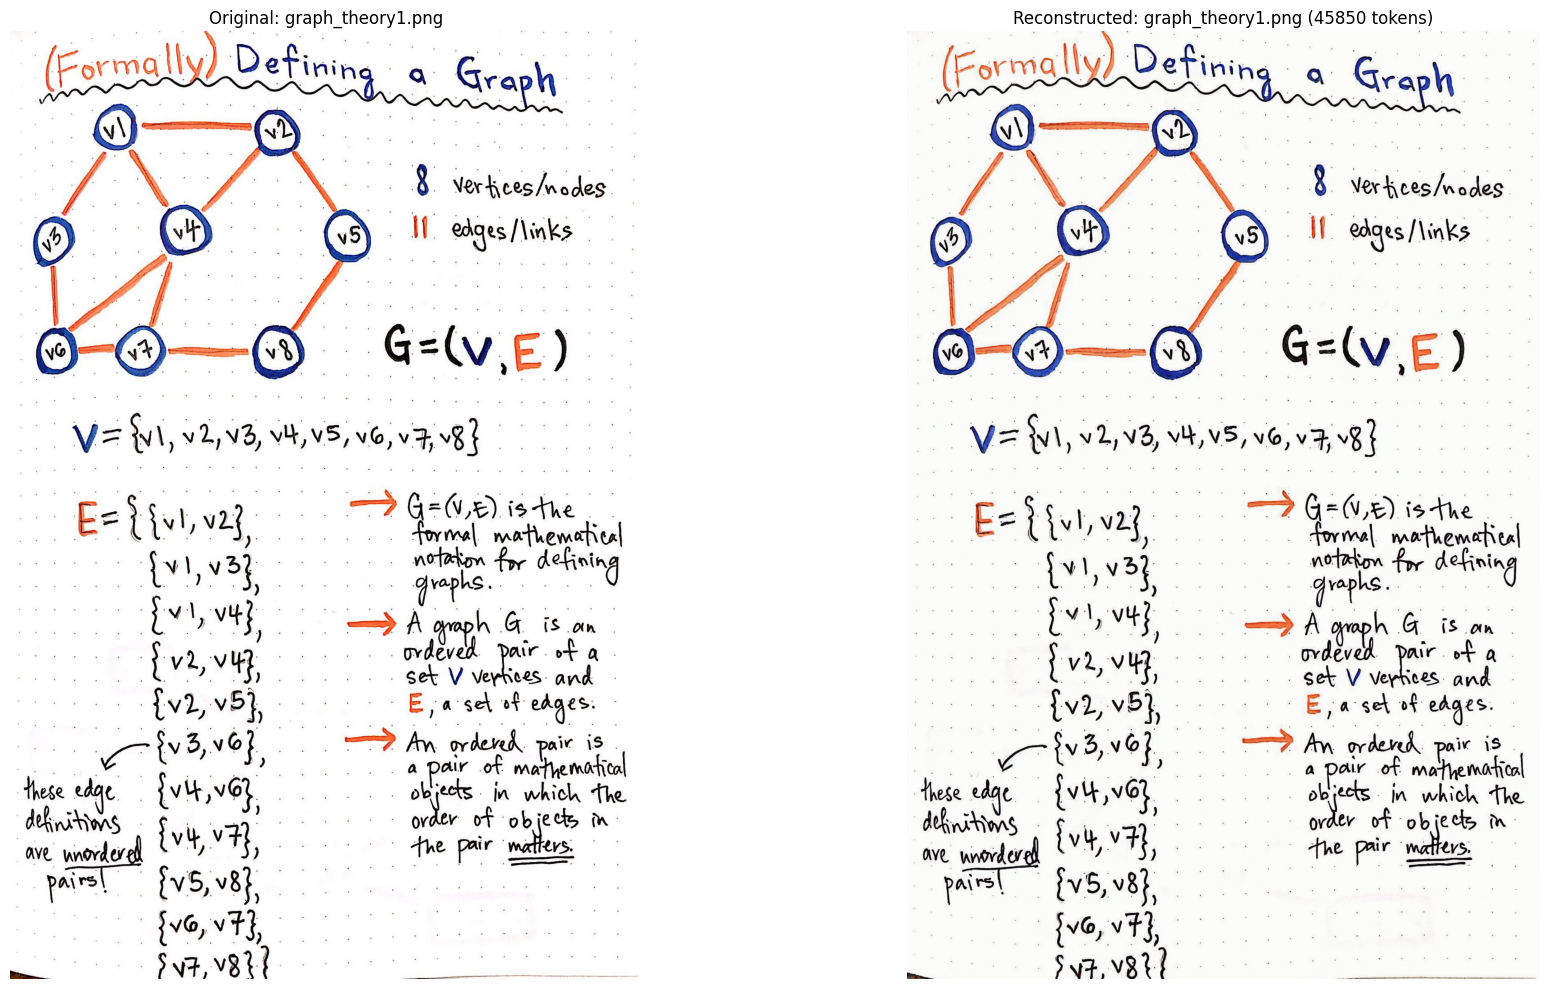


Processing image 2: line_chart.png
Input image shape: torch.Size([1, 3, 626, 712])
Number of tokens: 6942
Original image pixels: 445712
Compression ratio: 64.21x
Indices shape: torch.Size([6942])
Saved: line_chart_6942.png


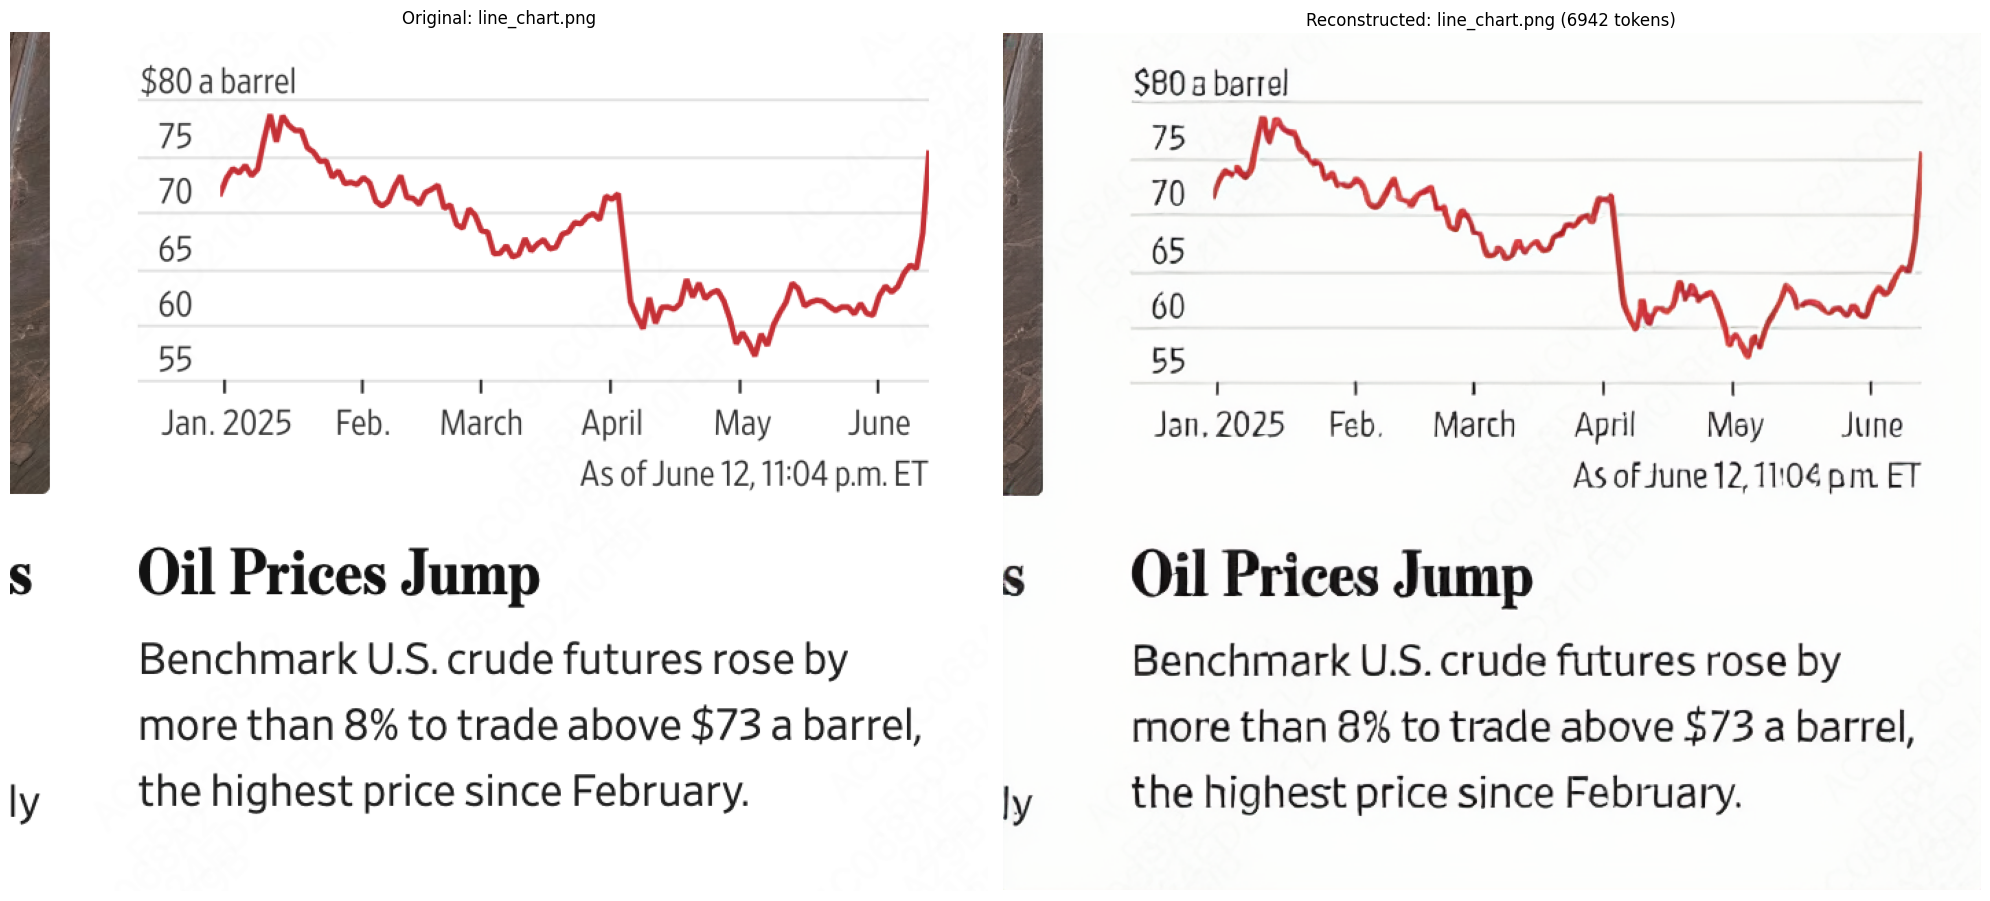


Processing image 3: logo1.png
Input image shape: torch.Size([1, 3, 935, 800])
Number of tokens: 11600
Original image pixels: 748000
Compression ratio: 64.48x
Indices shape: torch.Size([11600])
Saved: logo1_11600.png


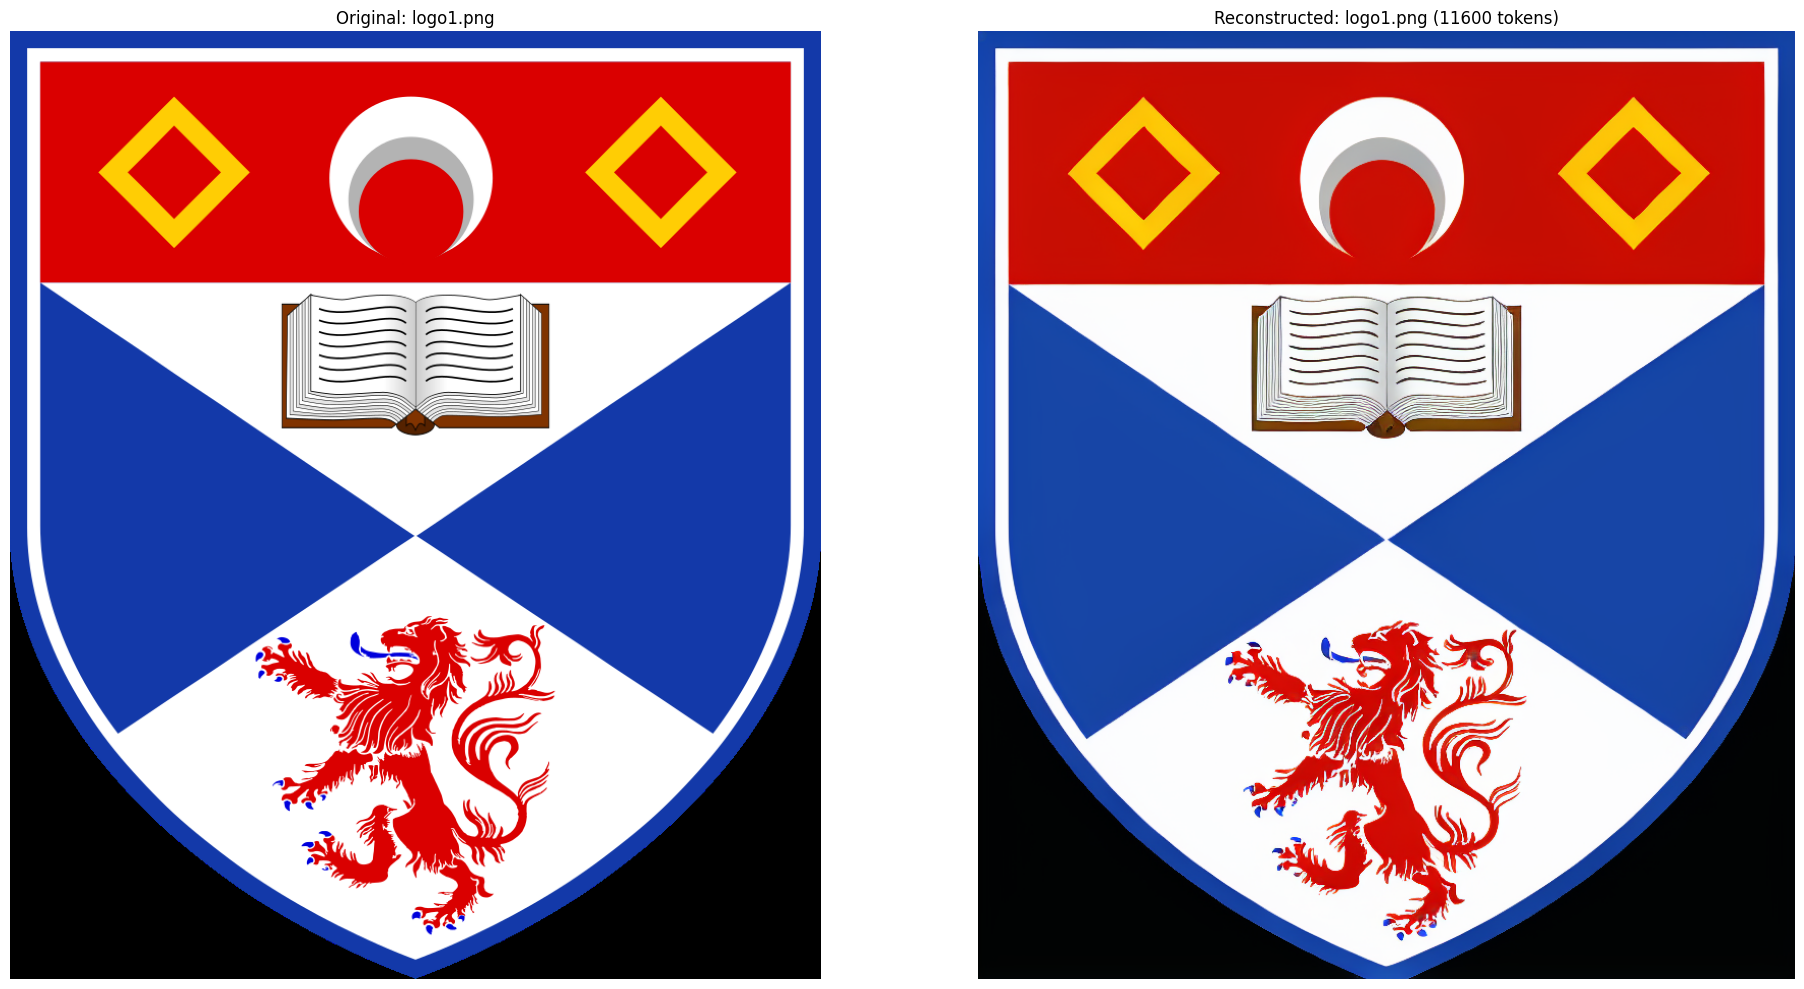


Processing image 4: logo2.png
Input image shape: torch.Size([1, 3, 586, 555])
Number of tokens: 5037
Original image pixels: 325230
Compression ratio: 64.57x
Indices shape: torch.Size([5037])
Saved: logo2_5037.png


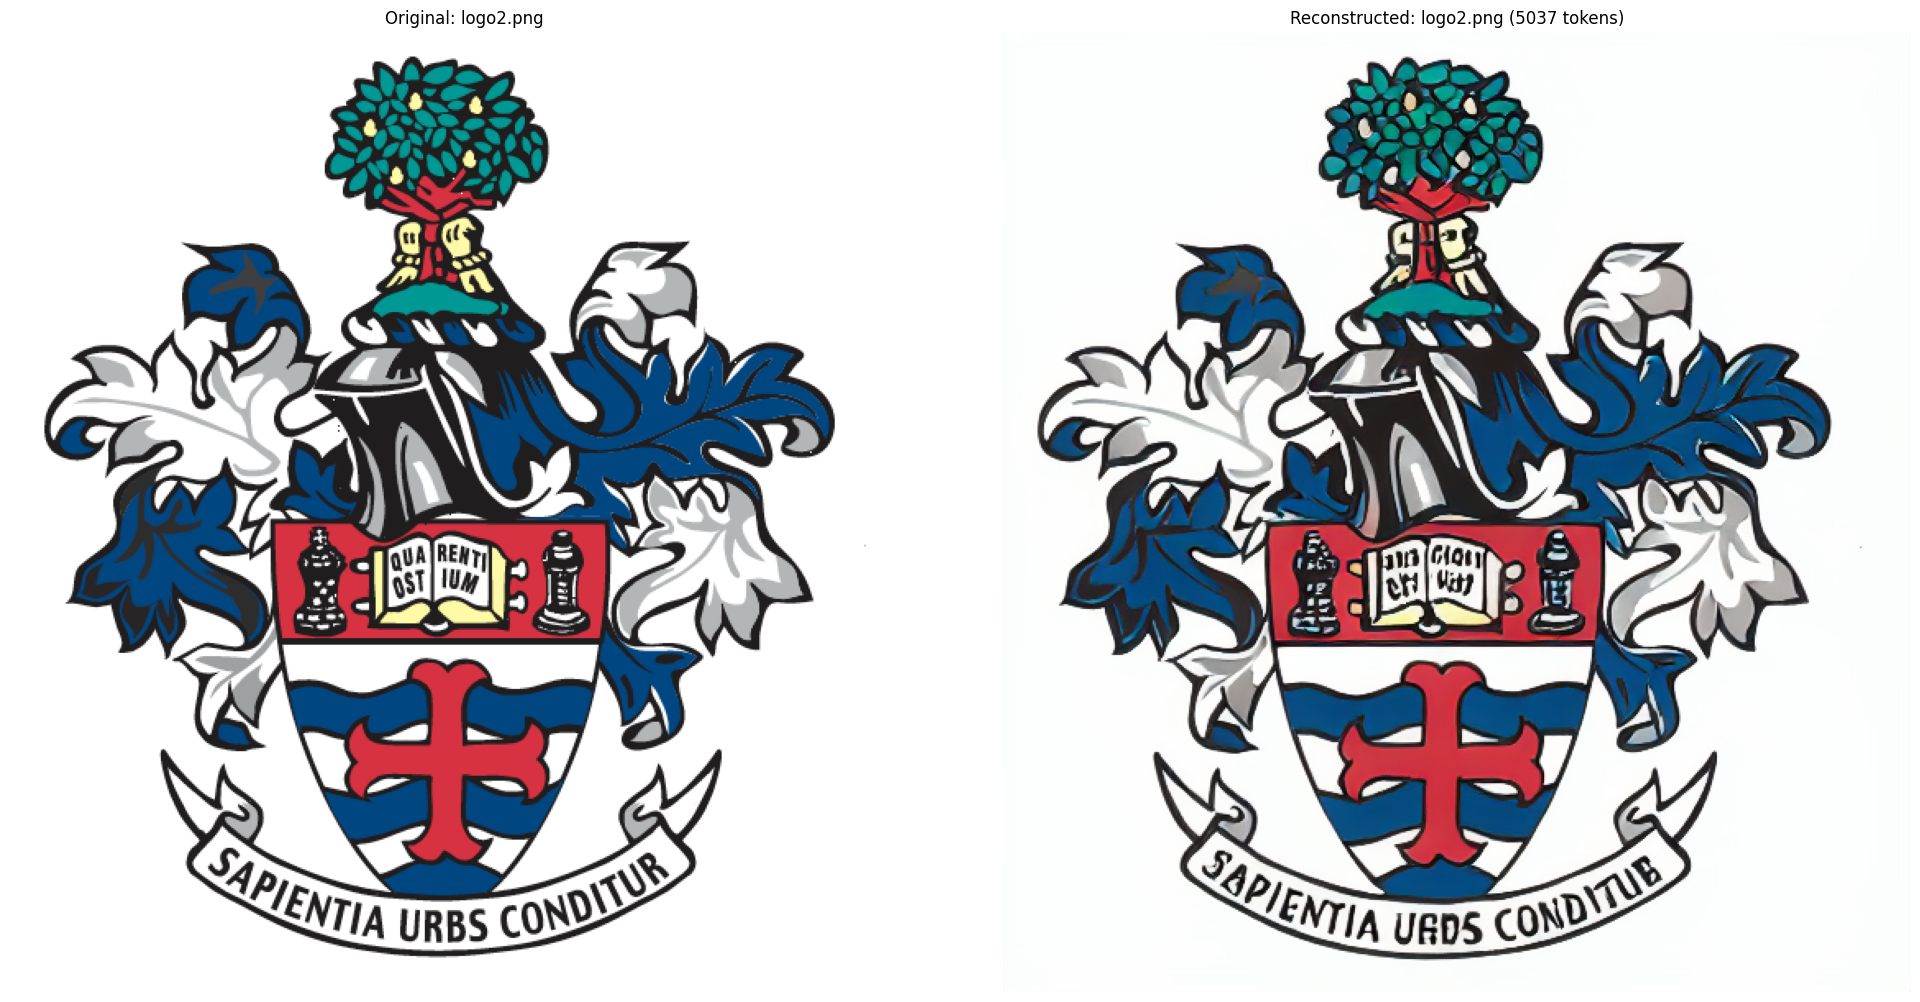


Processing image 5: math_draft1.png
Input image shape: torch.Size([1, 3, 864, 934])
Number of tokens: 12528
Original image pixels: 806976
Compression ratio: 64.41x
Indices shape: torch.Size([12528])
Saved: math_draft1_12528.png


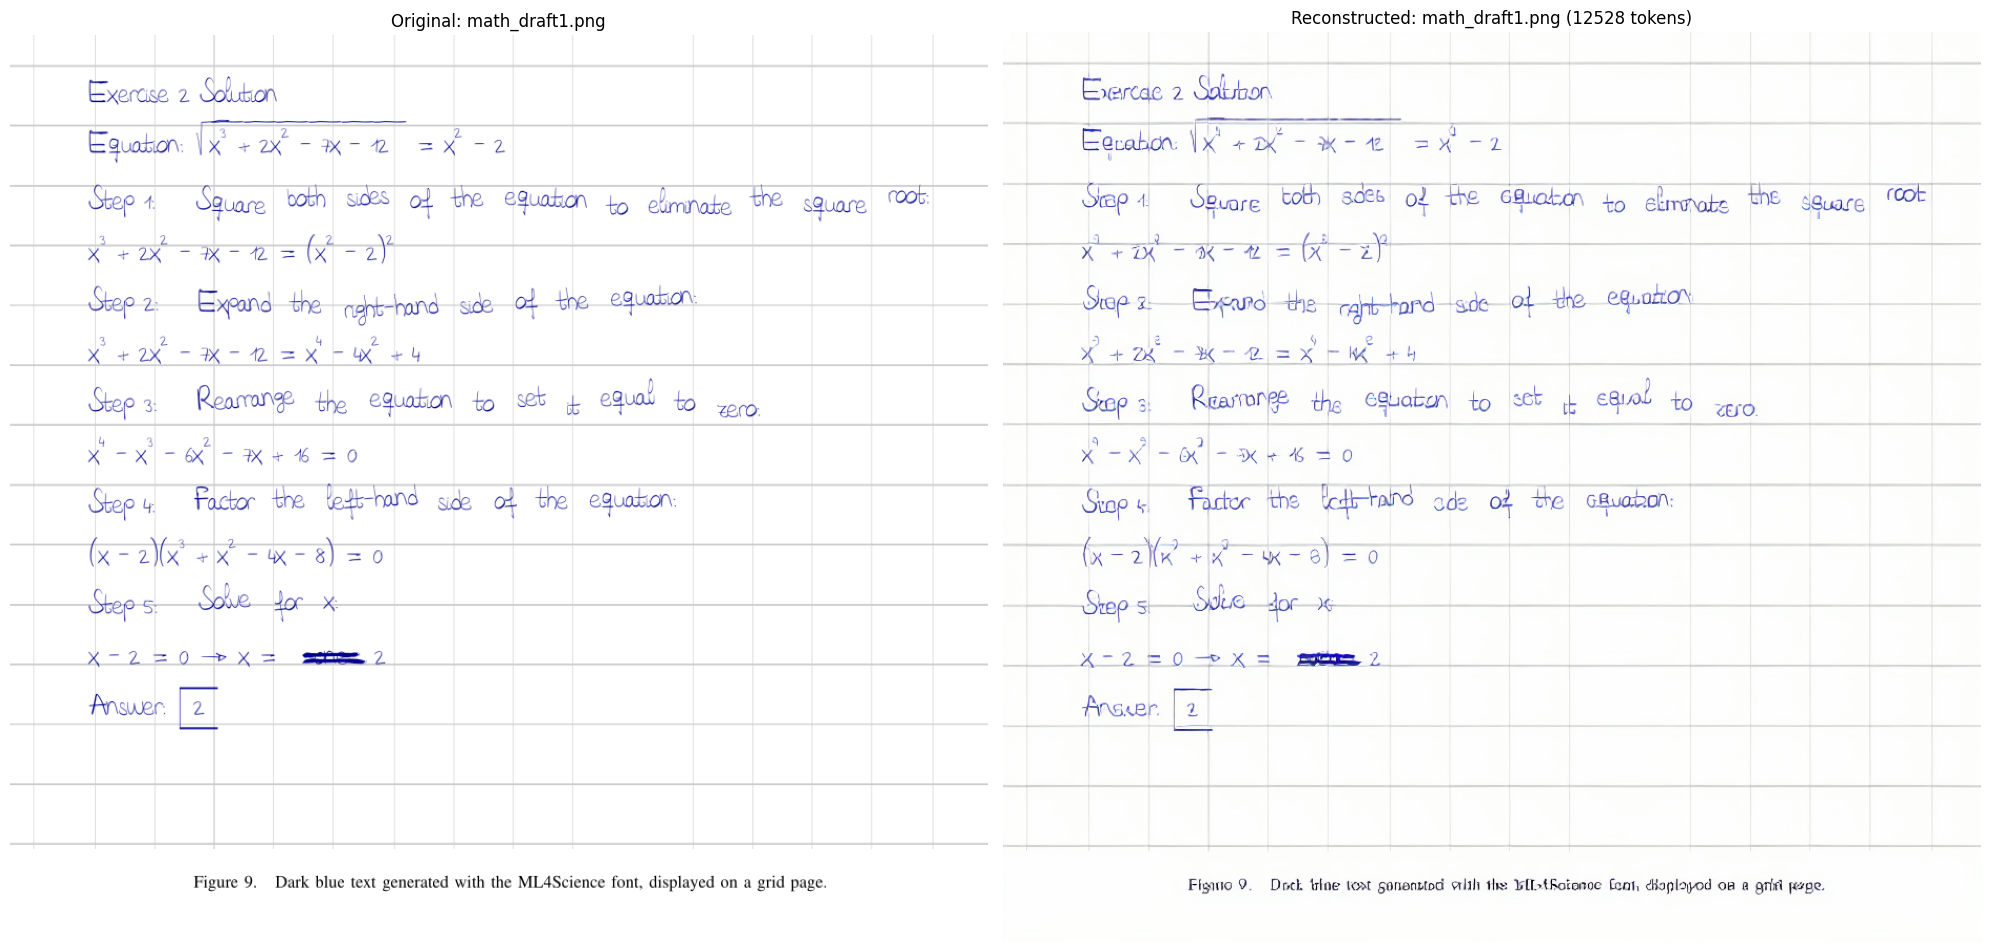


Processing image 6: menu.jpeg
Input image shape: torch.Size([1, 3, 2048, 1536])
Number of tokens: 49152
Original image pixels: 3145728
Compression ratio: 64.00x
Indices shape: torch.Size([49152])
Saved: menu_49152.png


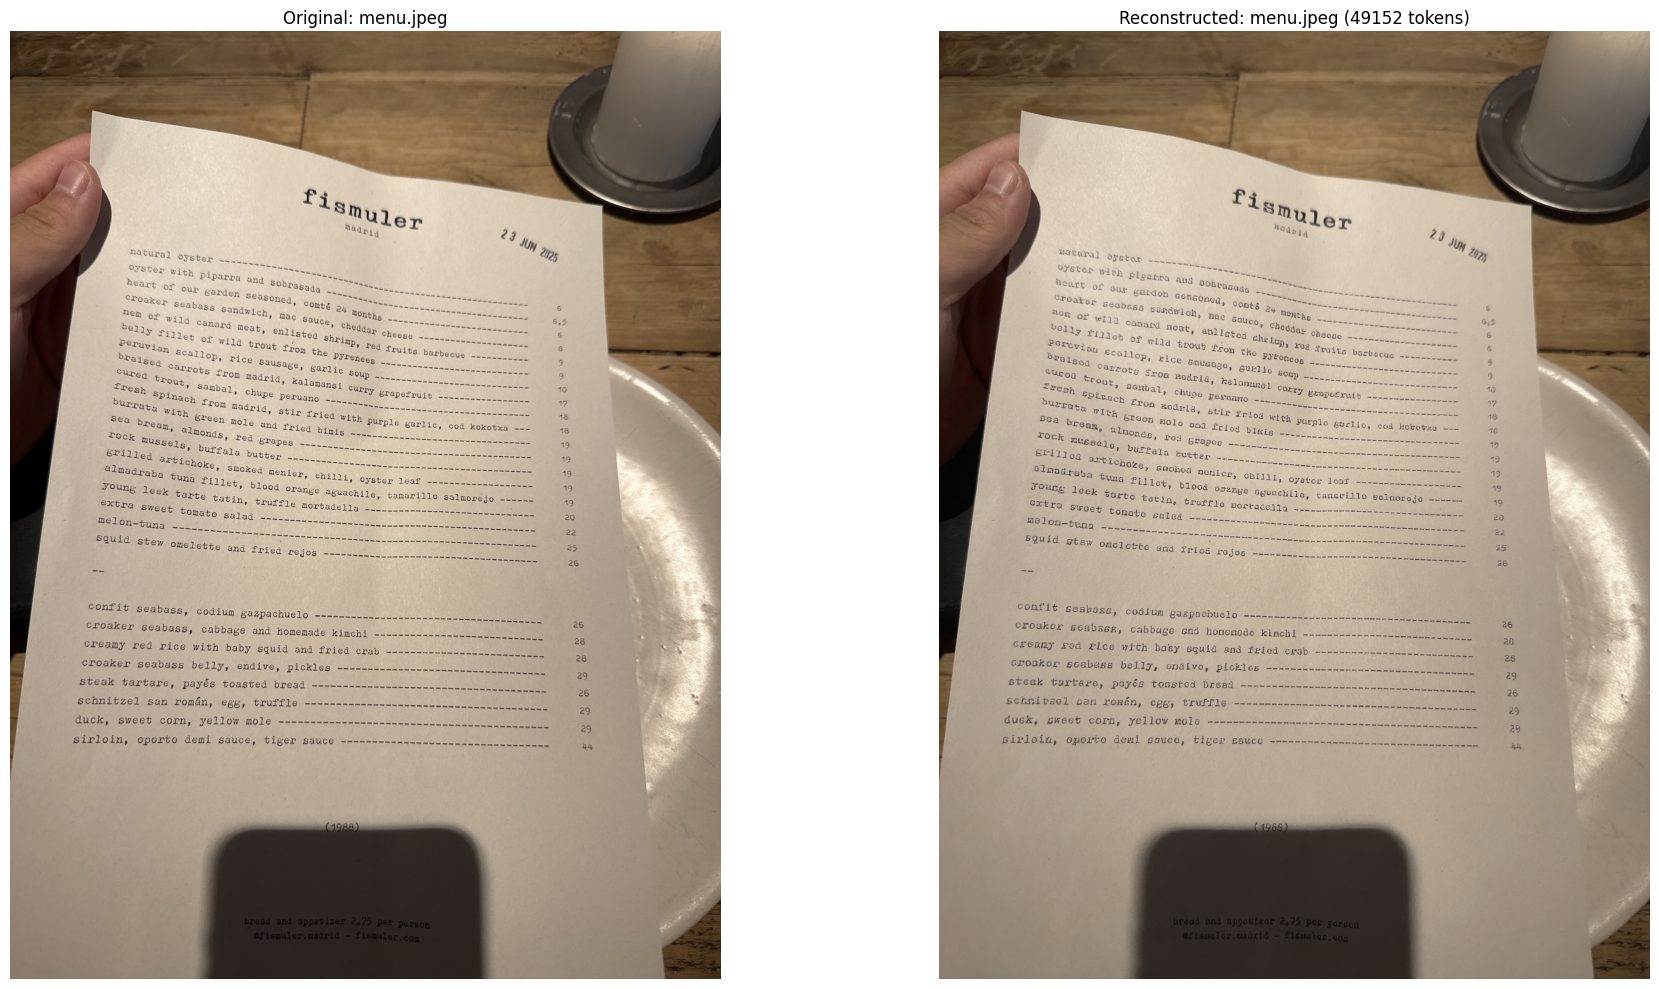


Processing image 7: physics1.png
Input image shape: torch.Size([1, 3, 270, 527])
Number of tokens: 2145
Original image pixels: 142290
Compression ratio: 66.34x
Indices shape: torch.Size([2145])
Saved: physics1_2145.png


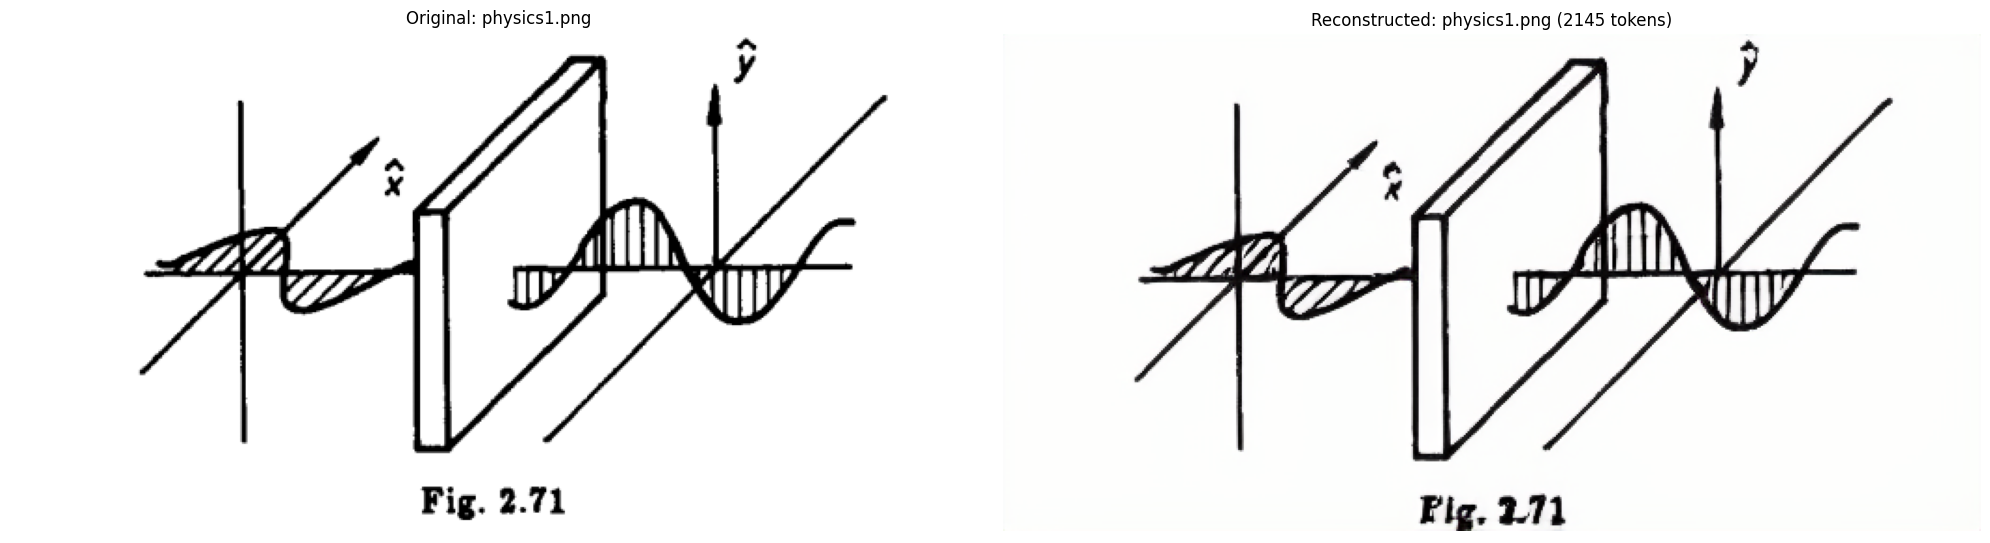


Processing image 8: physics2.png
Input image shape: torch.Size([1, 3, 341, 651])
Number of tokens: 3402
Original image pixels: 221991
Compression ratio: 65.25x
Indices shape: torch.Size([3402])
Saved: physics2_3402.png


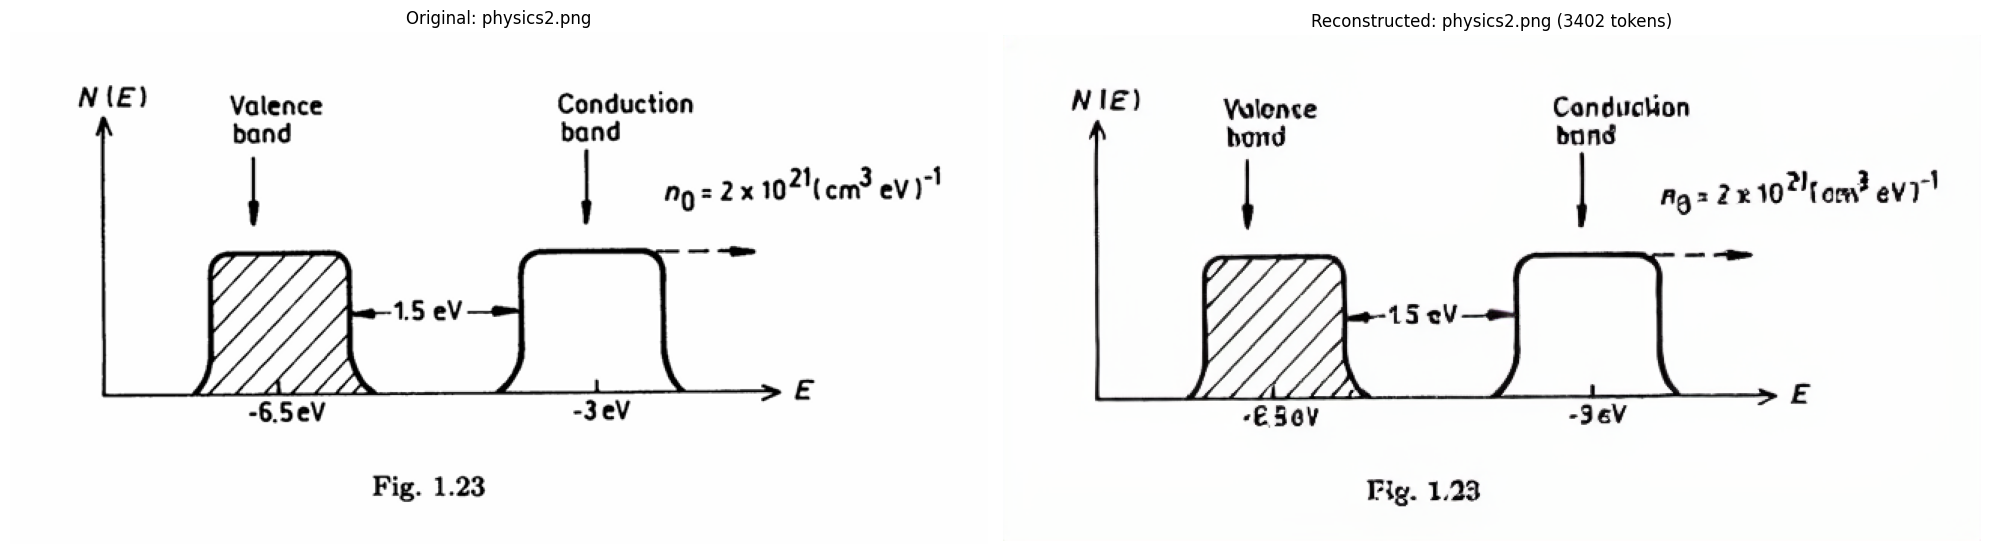

In [9]:
TOKENIZER = "vqgan_openimage_f8_16384" # vqgan_openimage_f8_256 , vqgan_openimage_f8_16384
RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{TOKENIZER}'
os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

# Initialize tokenizer
tokenizer = VQGAN(
    vqgan_model=TOKENIZER,  
)

for idx, image_path in enumerate(image_paths):
    name = Path(image_path).name
    print(f"\nProcessing image {idx+1}: {name}")
    
    # Load image
    image = Image.open(image_path).convert("RGB")
    
    # Use tokenizer's reconstruct method
    reconstructed_image, metrics = tokenizer.reconstruct(image)
    
    # Print metrics
    print(f"Input image shape: {metrics['input_shape']}")
    print(f"Number of tokens: {metrics['num_tokens']}")
    print(f"Original image pixels: {metrics['original_pixels']}")
    print(f"Compression ratio: {metrics['compression_ratio']:.2f}x")
    print(f"Indices shape: {metrics['indices_shape']}")
    
    # Save reconstructed image with number of tokens
    name_without_ext = Path(name).stem
    output_filename = f"{name_without_ext}_{metrics['num_tokens']}.png"
    output_path = os.path.join(RECONSTRUCTION_PATH, output_filename)
    reconstructed_image.save(output_path)
    print(f"Saved: {output_filename}")
    
    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title(f"Original: {name}")
    axes[0].axis('off')
    
    # Reconstructed image
    axes[1].imshow(reconstructed_image)
    axes[1].set_title(f"Reconstructed: {name} ({metrics['num_tokens']} tokens)")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    

In [8]:
# # Initialize tiler for normalized values
# tiler = Tiler(tile_size=256, pad_value=-1.0)
# batch_size = 8  # Adjust based on your GPU memory

# TOKENIZER = "LlamaGen_f8_16384_Tiled"
# RECONSTRUCTION_PATH = f'/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/{TOKENIZER}'
# os.makedirs(RECONSTRUCTION_PATH, exist_ok=True)

# for idx, image_path in enumerate(image_paths):
#     name = Path(image_path).name
#     print(f"\nProcessing image {idx+1}: {name}")
    
#     # Load image
#     image = Image.open(image_path).convert("RGB")
    
#     with torch.no_grad():
#         # Convert to tensor (matching the exact preprocessing)
#         if not image.mode == "RGB":
#             image = image.convert("RGB")
        
#         # Convert to numpy and normalize exactly like in ImagePaths.preprocess_image
#         image_np = np.array(image)
#         image_np = (image_np/127.5 - 1.0).astype(np.float32)

#         # Convert to tensor (CHW format, no batch dimension yet)
#         image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)
#         print(f"Normalized image shape: {image_tensor.shape}")
        
#         # Tile the normalized image
#         result = tiler(image_tensor)
#         tiles = result['tiles']  # Shape: (total_tiles, C, tile_h, tile_w)
#         metadata = result['metadata']
        
#         print(f"Number of tiles: {tiles.shape[0]}")
#         print(f"Tile shape: {tiles.shape[1:]}")
        
#         # Process tiles in batches to avoid OOM
#         total_tiles = tiles.shape[0]
#         reconstructed_tiles_list = []
#         all_indices = []
        
#         print(f"Processing {total_tiles} tiles in batches of {batch_size}")
        
#         for i in range(0, total_tiles, batch_size):
#             end_idx = min(i + batch_size, total_tiles)
#             batch_tiles = tiles[i:end_idx].to(tokenizer.device)
            
#             print(f"Processing batch {i//batch_size + 1}/{(total_tiles + batch_size - 1)//batch_size}: tiles {i+1}-{end_idx}")
            
#             # Process this batch through the tokenizer's encode/decode methods
#             indices, additional_info = tokenizer.encode(batch_tiles)
#             reconstructed_batch = tokenizer.decode(indices, additional_info)
            
#             # Clamp and move to CPU to save GPU memory
#             reconstructed_batch = reconstructed_batch.clamp(-1, 1).cpu()
#             reconstructed_tiles_list.append(reconstructed_batch)
#             all_indices.append(indices.cpu())
            
#             # Clear GPU memory
#             del batch_tiles, reconstructed_batch, indices
#             torch.cuda.empty_cache()
        
#         # Concatenate all results
#         reconstructed_tiles = torch.cat(reconstructed_tiles_list, dim=0)
#         all_indices_tensor = torch.cat(all_indices, dim=0)
        
#         print(f"Encoded codes shape: {all_indices_tensor.shape}")
        
#         # Calculate tokens and compression ratio
#         total_tokens = all_indices_tensor.numel()
#         original_pixels = image_tensor.shape[-2] * image_tensor.shape[-1]
#         compression_ratio = original_pixels / total_tokens
        
#         print(f"Total tokens across all tiles: {total_tokens}")
#         print(f"Original image pixels: {original_pixels}")
#         print(f"Compression ratio: {compression_ratio:.2f}x")
        
#         # Reconstruct full image from tiles
#         reconstructed_full = tiler.full_reconstruct(reconstructed_tiles, metadata)
        
#         print(f"Reconstructed image shape: {reconstructed_full.shape}")
        
#         # Convert to PIL for display and saving using tokenizer's postprocess
#         original_pil = image  # We already have the PIL image
#         reconstructed_image = tokenizer.postprocess(reconstructed_full.unsqueeze(0))  # Add batch dim
    
#     # Create metrics dict for consistency
#     metrics = {
#         'input_shape': image_tensor.shape,
#         'num_tokens': total_tokens,
#         'original_pixels': original_pixels,
#         'compression_ratio': compression_ratio,
#         'indices_shape': all_indices_tensor.shape,
#         'num_tiles': tiles.shape[0],
#         'tile_size': 256
#     }
    
#     # Print metrics
#     print(f"Input image shape: {metrics['input_shape']}")
#     print(f"Number of tokens: {metrics['num_tokens']}")
#     print(f"Original image pixels: {metrics['original_pixels']}")
#     print(f"Compression ratio: {metrics['compression_ratio']:.2f}x")
#     print(f"Indices shape: {metrics['indices_shape']}")
#     print(f"Number of tiles: {metrics['num_tiles']}")
    
#     # Save reconstructed image with number of tokens
#     name_without_ext = Path(name).stem
#     output_filename = f"{name_without_ext}_tiled_{metrics['num_tokens']}.png"
#     output_path = os.path.join(RECONSTRUCTION_PATH, output_filename)
#     reconstructed_image.save(output_path)
#     print(f"Saved: {output_filename}")
    
#     # Display comparison
#     fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    
#     # Original image
#     axes[0].imshow(original_pil)
#     axes[0].set_title(f"Original: {name}")
#     axes[0].axis('off')
    
#     # Reconstructed image
#     axes[1].imshow(reconstructed_image)
#     axes[1].set_title(f"Reconstructed: {name} ({metrics['num_tokens']} tokens, {metrics['num_tiles']} tiles)")
#     axes[1].axis('off')
    
#     plt.tight_layout()
#     plt.show()
    
#     # Optionally show all tiles in grid format
#     print("Displaying all tiles in grid:")
#     tiler.show_tiles(tiles.cpu(), metadata)